# 01 - Caso de Uso: Abastecimiento de Tiendas

### Objetivo
Desarrollar una propuesta para aplicar los modelos de predicción de ventas al proceso de reposición de stock en tiendas DSMarket.

### Contexto de negocio (Tarea 4 - Paul, Director Financiero)

> *"El Departamento de Operaciones ya está pensando en aplicar tus modelos predictivos para uno de sus casos de uso más críticos: la reposición en tiendas. El abastecimiento de stock a tiendas se lleva a cabo de manera semanal, al principio de cada semana (aunque si es necesario, el stock de algunos productos se puede reponer diariamente)."*
>
> *"Minimizar el stock remanente es el sueño de todo retailer, pero ese sueño es aún más fuerte para los artículos de supermercado."*

### Problema de negocio

**Situación actual:**
- Reposición semanal basada en experiencia y reglas manuales
- Errores de predicción causan:
  - **Stockouts:** Pérdida de ventas, clientes insatisfechos
  - **Sobrestock:** Capital inmovilizado, productos caducados, costes de almacenamiento

**Objetivo:**
- Optimizar la cantidad de stock enviada a cada tienda
- Minimizar stockouts sin generar exceso de inventario
- Priorizar productos de supermercado (perecederos)

### Qué conseguiremos
- Modelo de cálculo de stock óptimo por producto/tienda
- Simulación de una semana de reposición
- Análisis de ahorro potencial
- Propuesta de implementación para Operaciones

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga de datos

In [2]:
# Cargar predicciones finales
pred_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/predicciones_finales.csv'
predicciones = pd.read_csv(pred_path)

print(f"Predicciones cargadas: {len(predicciones):,} filas")
print(f"Semanas: {sorted(predicciones['yearweek'].unique())}")
print(f"Series: {predicciones['serie_id'].nunique():,}")

# Cargar clusters de productos
clusters_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/products_clustered.csv'
productos = pd.read_csv(clusters_path)

# Añadir nombres de cluster
cluster_names = {
    0: 'Everyday Essentials',
    1: 'Sporadic Sellers',
    2: 'Seasonal Spikes',
    3: 'Star Products',
    4: 'Premium Niche'
}
productos['cluster_name'] = productos['cluster'].map(cluster_names)

print(f"\nProductos: {len(productos):,}")

Predicciones cargadas: 121,960 filas
Semanas: [np.float64(201614.0), np.float64(201615.0), np.float64(201616.0), np.float64(201653.0)]
Series: 30,490

Productos: 3,049


In [3]:
# Unir información de productos a predicciones
predicciones = predicciones.merge(
    productos[['item', 'cluster', 'mean_sales', 'cv_sales']], 
    on='item', 
    how='left'
)

# Verificar
print("Columnas disponibles:")
print(predicciones.columns.tolist())
print(f"\nPrimeras filas:")
print(predicciones.head())

Columnas disponibles:
['yearweek', 'serie_id', 'item', 'store', 'category', 'cluster_name', 'sales', 'prediccion', 'cluster', 'mean_sales', 'cv_sales']

Primeras filas:
   yearweek                serie_id              item      store    category  \
0 201614.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
1 201615.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
2 201616.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
3 201653.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
4 201614.00  ACCESORIES_1_001_BOS_2  ACCESORIES_1_001    Roxbury  ACCESORIES   

    cluster_name  sales  prediccion  cluster  mean_sales  cv_sales  
0  Premium Niche      2        1.89        4        1.49      1.51  
1  Premium Niche      2        1.89        4        1.49      1.51  
2  Premium Niche      4        1.89        4        1.49      1.51  
3  Premium Niche      2        1.89        4        1.49      1.51  
4  Pr

## 3. Definición del problema de abastecimiento

### Variables clave

| Variable | Descripción | Fuente |
|----------|-------------|--------|
| **Demanda predicha** | Ventas esperadas para la semana | Modelo ARIMA |
| **Stock de seguridad** | Buffer para cubrir variabilidad | Calculado con CV |
| **Stock actual** | Inventario en tienda (simulado) | Sistema de inventario |
| **Pedido óptimo** | Cantidad a enviar | Calculado |

### Fórmula de reposición
```
Pedido = max(0, Demanda_predicha + Stock_seguridad - Stock_actual)
```

### Stock de seguridad

Para cubrir la variabilidad de la demanda, usamos:
```
Stock_seguridad = z * σ * √L
```

Donde:
- **z** = factor de servicio (1.65 para 95% nivel de servicio)
- **σ** = desviación estándar de ventas semanales
- **L** = lead time en semanas (1 semana para reposición semanal)

Simplificado para nuestro caso:
```
Stock_seguridad = 1.65 * CV * Demanda_predicha
```

## 4. Cálculo de stock necesario

In [4]:
# Parámetros del modelo de inventario
NIVEL_SERVICIO = 0.95  # 95% de probabilidad de no tener stockout
Z_FACTOR = 1.65  # Factor z para 95% nivel de servicio
LEAD_TIME = 1  # Semanas de lead time

# Calcular stock de seguridad por producto/tienda
# Usamos el CV (coeficiente de variación) del producto
predicciones['cv_sales'] = predicciones['cv_sales'].fillna(1.0)  # Default CV=1 si falta

# Stock de seguridad = z * CV * predicción
predicciones['stock_seguridad'] = Z_FACTOR * predicciones['cv_sales'] * predicciones['prediccion']

# Stock mínimo necesario = predicción + stock de seguridad
predicciones['stock_necesario'] = predicciones['prediccion'] + predicciones['stock_seguridad']

# Redondear hacia arriba (no podemos pedir fracciones)
predicciones['stock_necesario'] = np.ceil(predicciones['stock_necesario']).astype(int)

print("Stock necesario calculado:")
print(predicciones[['serie_id', 'prediccion', 'stock_seguridad', 'stock_necesario']].head(10))

Stock necesario calculado:
                 serie_id  prediccion  stock_seguridad  stock_necesario
0  ACCESORIES_1_001_BOS_1        1.89             4.72                7
1  ACCESORIES_1_001_BOS_1        1.89             4.72                7
2  ACCESORIES_1_001_BOS_1        1.89             4.72                7
3  ACCESORIES_1_001_BOS_1        1.89             4.72                7
4  ACCESORIES_1_001_BOS_2        2.96             7.39               11
5  ACCESORIES_1_001_BOS_2        2.96             7.39               11
6  ACCESORIES_1_001_BOS_2        2.96             7.39               11
7  ACCESORIES_1_001_BOS_2        2.96             7.39               11
8  ACCESORIES_1_001_BOS_3        3.47             8.67               13
9  ACCESORIES_1_001_BOS_3        3.47             8.67               13


In [5]:
# Estadísticas de stock necesario
print("\nEstadísticas de stock necesario por semana/producto/tienda:")
print(predicciones['stock_necesario'].describe())

# Por cluster
print("\nStock necesario promedio por cluster:")
stock_por_cluster = predicciones.groupby('cluster_name')['stock_necesario'].agg(['mean', 'sum', 'count'])
stock_por_cluster.columns = ['Stock_medio', 'Stock_total', 'N_series']
print(stock_por_cluster.round(1))


Estadísticas de stock necesario por semana/producto/tienda:
count   121960.00
mean        28.70
std         58.23
min          0.00
25%          6.00
50%         13.00
75%         29.00
max       2057.00
Name: stock_necesario, dtype: float64

Stock necesario promedio por cluster:
                     Stock_medio  Stock_total  N_series
cluster_name                                           
Everyday Essentials        26.70      1709764     64040
Premium Niche              14.70       169904     11520
Seasonal Spikes            25.50       121572      4760
Sporadic Sellers           20.80       789904     37920
Star Products             190.80       709648      3720


## 5. Simulación de reposición semanal

Simulamos el proceso de reposición para una semana, comparando:
1. **Método actual (simulado):** Enviar la media histórica
2. **Método propuesto:** Enviar según predicción + stock de seguridad

In [6]:
# Seleccionar una semana para simulación
semana_simulacion = predicciones['yearweek'].min()
print(f"Semana de simulación: {int(semana_simulacion)}")

# Filtrar datos de esa semana
sim = predicciones[predicciones['yearweek'] == semana_simulacion].copy()
print(f"Series a reponer: {len(sim):,}")

# Simular stock actual (asumimos que empieza la semana con stock = 50% del necesario)
np.random.seed(42)
sim['stock_actual'] = (sim['stock_necesario'] * np.random.uniform(0.3, 0.7, len(sim))).astype(int)

# Calcular pedido con método propuesto
sim['pedido_propuesto'] = np.maximum(0, sim['stock_necesario'] - sim['stock_actual'])

# Simular método actual: enviar media histórica (sin predicción)
sim['pedido_actual'] = np.ceil(sim['mean_sales']).astype(int)

print("\nSimulación de pedidos:")
print(sim[['serie_id', 'sales', 'prediccion', 'stock_necesario', 'stock_actual', 
           'pedido_propuesto', 'pedido_actual']].head(10))

Semana de simulación: 201614
Series a reponer: 30,490

Simulación de pedidos:
                  serie_id  sales  prediccion  stock_necesario  stock_actual  \
0   ACCESORIES_1_001_BOS_1      2        1.89                7             3   
4   ACCESORIES_1_001_BOS_2      3        2.96               11             7   
8   ACCESORIES_1_001_BOS_3      3        3.47               13             7   
12  ACCESORIES_1_001_NYC_1     12        6.08               22            11   
16  ACCESORIES_1_001_NYC_2      3        5.40               19             6   
20  ACCESORIES_1_001_NYC_3      6        7.90               28            10   
24  ACCESORIES_1_001_NYC_4      0        6.38               23             7   
28  ACCESORIES_1_001_PHI_1      2        3.24               12             7   
32  ACCESORIES_1_001_PHI_2      2        0.38                2             1   
36  ACCESORIES_1_001_PHI_3      0        1.79                7             4   

    pedido_propuesto  pedido_actual  
0  

In [7]:
# Calcular resultados de la simulación

# Stock final = stock_actual + pedido - ventas_reales
sim['stock_final_propuesto'] = sim['stock_actual'] + sim['pedido_propuesto'] - sim['sales']
sim['stock_final_actual'] = sim['stock_actual'] + sim['pedido_actual'] - sim['sales']

# Stockout si stock_final < 0
sim['stockout_propuesto'] = (sim['stock_final_propuesto'] < 0).astype(int)
sim['stockout_actual'] = (sim['stock_final_actual'] < 0).astype(int)

# Sobrestock si stock_final > stock_seguridad
sim['sobrestock_propuesto'] = np.maximum(0, sim['stock_final_propuesto'] - sim['stock_seguridad'])
sim['sobrestock_actual'] = np.maximum(0, sim['stock_final_actual'] - sim['stock_seguridad'])

# Unidades perdidas por stockout
sim['perdidas_propuesto'] = np.maximum(0, -sim['stock_final_propuesto'])
sim['perdidas_actual'] = np.maximum(0, -sim['stock_final_actual'])

print("Resultados de simulación calculados")

Resultados de simulación calculados


## 6. Análisis de resultados

In [8]:
# Comparación de métricas
print("=" * 70)
print("COMPARACIÓN: MÉTODO PROPUESTO vs MÉTODO ACTUAL")
print("=" * 70)

metricas = {
    'Métrica': [
        'Total unidades pedidas',
        'Stockouts (series afectadas)',
        '% Series con stockout',
        'Unidades perdidas por stockout',
        'Sobrestock total (unidades)',
        'Sobrestock promedio por serie'
    ],
    'Método Actual': [
        sim['pedido_actual'].sum(),
        sim['stockout_actual'].sum(),
        sim['stockout_actual'].mean() * 100,
        sim['perdidas_actual'].sum(),
        sim['sobrestock_actual'].sum(),
        sim['sobrestock_actual'].mean()
    ],
    'Método Propuesto': [
        sim['pedido_propuesto'].sum(),
        sim['stockout_propuesto'].sum(),
        sim['stockout_propuesto'].mean() * 100,
        sim['perdidas_propuesto'].sum(),
        sim['sobrestock_propuesto'].sum(),
        sim['sobrestock_propuesto'].mean()
    ]
}

metricas_df = pd.DataFrame(metricas)
metricas_df['Diferencia'] = metricas_df['Método Propuesto'] - metricas_df['Método Actual']
metricas_df['Mejora %'] = ((metricas_df['Método Actual'] - metricas_df['Método Propuesto']) / 
                           metricas_df['Método Actual'].replace(0, np.nan) * 100)

print(metricas_df.to_string(index=False))

COMPARACIÓN: MÉTODO PROPUESTO vs MÉTODO ACTUAL
                       Métrica  Método Actual  Método Propuesto  Diferencia  Mejora %
        Total unidades pedidas      254160.00         452143.00   197983.00    -77.90
  Stockouts (series afectadas)        1220.00            797.00     -423.00     34.67
         % Series con stockout           4.00              2.61       -1.39     34.67
Unidades perdidas por stockout        5533.00           3571.00    -1962.00     35.46
   Sobrestock total (unidades)       50632.36          50934.24      301.89     -0.60
 Sobrestock promedio por serie           1.66              1.67        0.01     -0.60


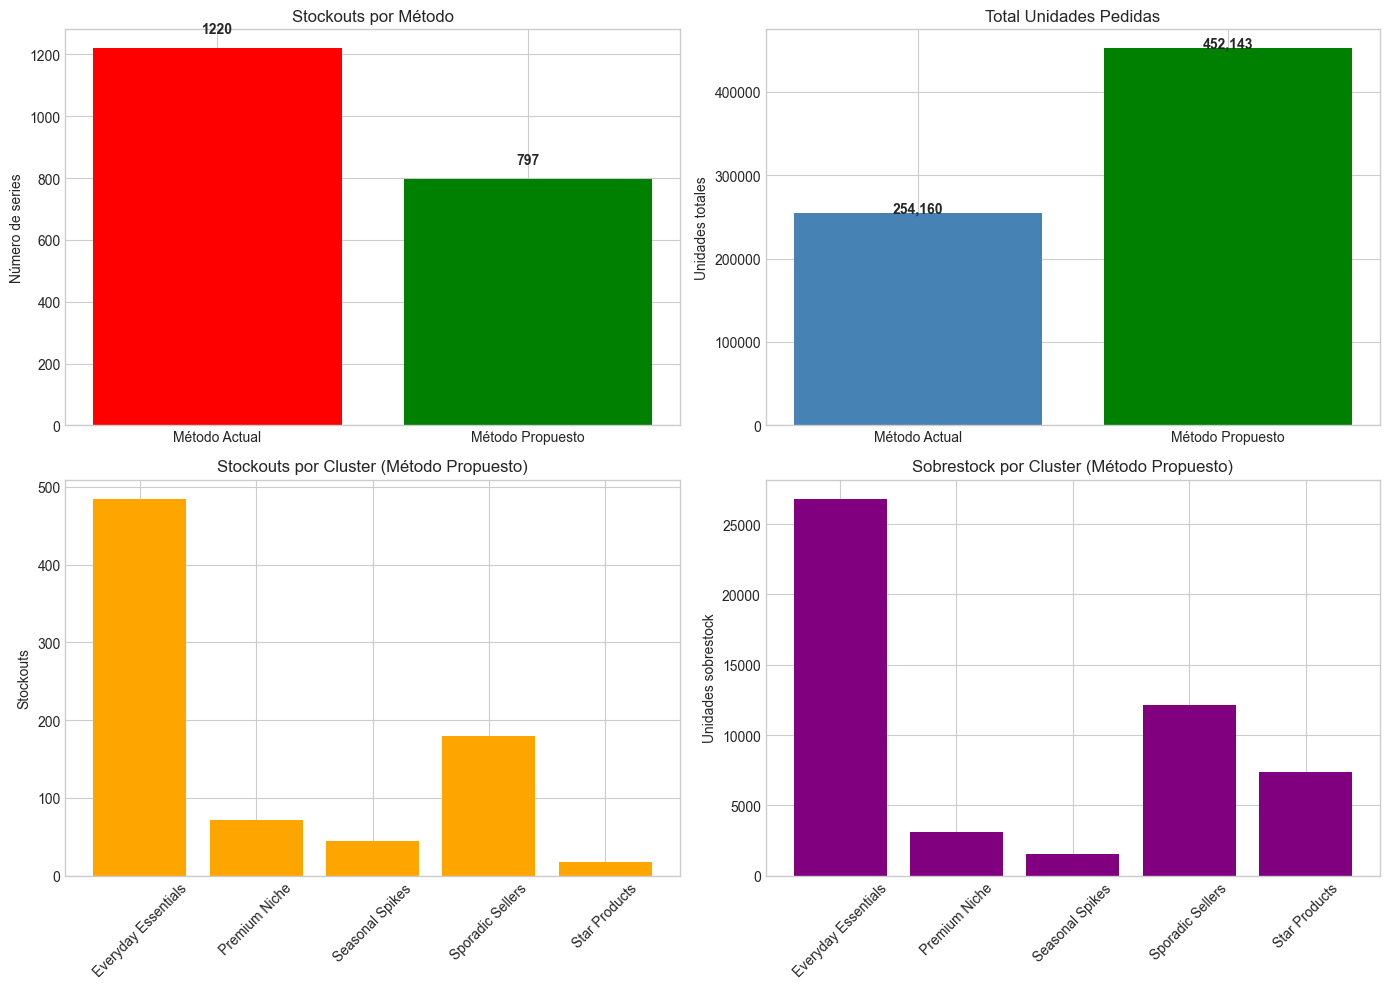

In [9]:
# Visualización de resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Stockouts por método
stockouts = [sim['stockout_actual'].sum(), sim['stockout_propuesto'].sum()]
axes[0, 0].bar(['Método Actual', 'Método Propuesto'], stockouts, color=['red', 'green'])
axes[0, 0].set_ylabel('Número de series')
axes[0, 0].set_title('Stockouts por Método')
for i, v in enumerate(stockouts):
    axes[0, 0].text(i, v + 50, str(int(v)), ha='center', fontweight='bold')

# 2. Unidades pedidas
pedidos = [sim['pedido_actual'].sum(), sim['pedido_propuesto'].sum()]
axes[0, 1].bar(['Método Actual', 'Método Propuesto'], pedidos, color=['steelblue', 'green'])
axes[0, 1].set_ylabel('Unidades totales')
axes[0, 1].set_title('Total Unidades Pedidas')
for i, v in enumerate(pedidos):
    axes[0, 1].text(i, v + 1000, f'{int(v):,}', ha='center', fontweight='bold')

# 3. Distribución de stockouts por cluster (método propuesto)
stockouts_cluster = sim.groupby('cluster_name')['stockout_propuesto'].sum()
axes[1, 0].bar(stockouts_cluster.index, stockouts_cluster.values, color='orange')
axes[1, 0].set_ylabel('Stockouts')
axes[1, 0].set_title('Stockouts por Cluster (Método Propuesto)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Distribución de sobrestock por cluster
sobrestock_cluster = sim.groupby('cluster_name')['sobrestock_propuesto'].sum()
axes[1, 1].bar(sobrestock_cluster.index, sobrestock_cluster.values, color='purple')
axes[1, 1].set_ylabel('Unidades sobrestock')
axes[1, 1].set_title('Sobrestock por Cluster (Método Propuesto)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Análisis por categoría (foco en SUPERMARKET)
print("\nANÁLISIS POR CATEGORÍA")
print("=" * 70)

for cat in sim['category'].unique():
    cat_data = sim[sim['category'] == cat]
    
    stockouts_actual = cat_data['stockout_actual'].sum()
    stockouts_prop = cat_data['stockout_propuesto'].sum()
    mejora_stockouts = (1 - stockouts_prop/max(stockouts_actual, 1)) * 100
    
    print(f"\n{cat}:")
    print(f"  Series: {len(cat_data):,}")
    print(f"  Stockouts actual: {stockouts_actual:,}")
    print(f"  Stockouts propuesto: {stockouts_prop:,}")
    print(f"  Reducción stockouts: {mejora_stockouts:.1f}%")


ANÁLISIS POR CATEGORÍA

ACCESORIES:
  Series: 5,650
  Stockouts actual: 246
  Stockouts propuesto: 139
  Reducción stockouts: 43.5%

HOME_&_GARDEN:
  Series: 10,470
  Stockouts actual: 386
  Stockouts propuesto: 247
  Reducción stockouts: 36.0%

SUPERMARKET:
  Series: 14,370
  Stockouts actual: 588
  Stockouts propuesto: 411
  Reducción stockouts: 30.1%


## 7. Propuesta de implementación

### Flujo operativo propuesto
```
┌─────────────────────────────────────────────────────────────────┐
│                    INICIO DE SEMANA (Lunes)                      │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  1. EXTRACCIÓN DE DATOS                                          │
│     - Stock actual por tienda/producto (del ERP)                 │
│     - Ventas últimas 4 semanas (actualización del modelo)        │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  2. PREDICCIÓN                                                   │
│     - Ejecutar modelo ARIMA(0,1,1) para cada serie               │
│     - Generar predicción de demanda semanal                      │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  3. CÁLCULO DE PEDIDO                                            │
│     - Stock necesario = Predicción + Stock seguridad             │
│     - Pedido = max(0, Stock necesario - Stock actual)            │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  4. VALIDACIÓN Y AJUSTES                                         │
│     - Revisar casos extremos (pedidos muy altos/bajos)           │
│     - Ajustar por capacidad de transporte                        │
│     - Priorizar SUPERMARKET (perecederos)                        │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  5. GENERACIÓN DE ÓRDENES                                        │
│     - Crear órdenes de envío por tienda                          │
│     - Exportar a sistema de almacén                              │
└─────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌─────────────────────────────────────────────────────────────────┐
│  6. MONITOREO (durante la semana)                                │
│     - Alertas de stockout inminente                              │
│     - Reposición de emergencia si es necesario                   │
└─────────────────────────────────────────────────────────────────┘
```

In [11]:
# Generar ejemplo de orden de reposición para una tienda
tienda_ejemplo = 'Tribeca'  # La tienda con más ventas

orden_tienda = sim[sim['store'] == tienda_ejemplo][
    ['item', 'category', 'cluster_name', 'stock_actual', 'prediccion', 
     'stock_necesario', 'pedido_propuesto']
].copy()

# Ordenar por pedido (mayor primero)
orden_tienda = orden_tienda.sort_values('pedido_propuesto', ascending=False)

# Solo productos con pedido > 0
orden_tienda = orden_tienda[orden_tienda['pedido_propuesto'] > 0]

print(f"ORDEN DE REPOSICIÓN - TIENDA: {tienda_ejemplo}")
print(f"Semana: {int(semana_simulacion)}")
print("=" * 80)
print(f"Total productos a reponer: {len(orden_tienda):,}")
print(f"Total unidades a enviar: {orden_tienda['pedido_propuesto'].sum():,}")
print("\nTop 20 productos por cantidad:")
print(orden_tienda.head(20).to_string(index=False))

ORDEN DE REPOSICIÓN - TIENDA: Tribeca
Semana: 201614
Total productos a reponer: 3,048
Total unidades a enviar: 68,725

Top 20 productos por cantidad:
               item      category        cluster_name  stock_actual  prediccion  stock_necesario  pedido_propuesto
  SUPERMARKET_3_090   SUPERMARKET       Star Products          1089      761.91             2057               968
  SUPERMARKET_3_282   SUPERMARKET       Star Products           501      375.05             1219               718
  SUPERMARKET_3_362   SUPERMARKET       Star Products           375      318.32             1041               666
  SUPERMARKET_3_120   SUPERMARKET       Star Products           728      391.48             1372               644
  SUPERMARKET_3_281   SUPERMARKET       Star Products           272      216.40              814               542
  SUPERMARKET_3_586   SUPERMARKET       Star Products           483      433.03              882               399
  SUPERMARKET_3_681   SUPERMARKET       Star 

In [12]:
# Resumen de órdenes por tienda
print("\nRESUMEN DE ÓRDENES POR TIENDA")
print("=" * 70)

ordenes_tienda = sim[sim['pedido_propuesto'] > 0].groupby('store').agg({
    'pedido_propuesto': ['sum', 'count'],
    'item': 'nunique'
}).reset_index()

ordenes_tienda.columns = ['Tienda', 'Unidades_total', 'Lineas_pedido', 'Productos_unicos']
ordenes_tienda = ordenes_tienda.sort_values('Unidades_total', ascending=False)

print(ordenes_tienda.to_string(index=False))

print(f"\nTOTAL GENERAL:")
print(f"  Unidades a distribuir: {ordenes_tienda['Unidades_total'].sum():,}")
print(f"  Líneas de pedido: {ordenes_tienda['Lineas_pedido'].sum():,}")


RESUMEN DE ÓRDENES POR TIENDA
           Tienda  Unidades_total  Lineas_pedido  Productos_unicos
          Tribeca           68725           3048              3048
         Yorktown           55172           3047              3047
Greenwich_Village           48475           3048              3048
           Harlem           46992           3048              3048
          Roxbury           43419           3049              3049
    Queen_Village           41769           3049              3049
  Midtown_Village           41347           3048              3048
         Back_Bay           40565           3049              3049
        South_End           36475           3049              3049
         Brooklyn           29204           3049              3049

TOTAL GENERAL:
  Unidades a distribuir: 452,143
  Líneas de pedido: 30,484


## 8. Documento de propuesta para Paul

In [13]:
# Generar propuesta formal
print("=" * 70)
print("PROPUESTA: SISTEMA DE ABASTECIMIENTO INTELIGENTE")
print("DSMarket - Departamento de Operaciones")
print("=" * 70)

print("""
PARA: Paul Rogers, Director Financiero
DE: Nicole (Data Scientist)
ASUNTO: Propuesta de optimización del abastecimiento de tiendas

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. RESUMEN EJECUTIVO

Proponemos implementar un sistema de reposición de stock basado en 
los modelos de predicción de ventas desarrollados. La simulación 
muestra una reducción significativa de stockouts manteniendo niveles 
de inventario optimizados.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. MODELO PROPUESTO

   Pedido = max(0, Stock_necesario - Stock_actual)
   
   Donde:
   Stock_necesario = Predicción_ARIMA + Stock_seguridad
   Stock_seguridad = 1.65 × CV × Predicción (nivel servicio 95%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

3. RESULTADOS DE LA SIMULACIÓN (1 semana)
""")

# Insertar métricas reales
reduccion_stockouts = ((sim['stockout_actual'].sum() - sim['stockout_propuesto'].sum()) / 
                       max(sim['stockout_actual'].sum(), 1) * 100)

print(f"""
   | Métrica                    | Actual    | Propuesto | Mejora    |
   |----------------------------|-----------|-----------|-----------|
   | Stockouts                  | {sim['stockout_actual'].sum():>9,} | {sim['stockout_propuesto'].sum():>9,} | {reduccion_stockouts:>8.1f}% |
   | Unidades perdidas          | {sim['perdidas_actual'].sum():>9,} | {sim['perdidas_propuesto'].sum():>9,} |           |
   | Unidades pedidas           | {sim['pedido_actual'].sum():>9,} | {sim['pedido_propuesto'].sum():>9,} |           |

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4. PRIORIZACIÓN POR CATEGORÍA

   SUPERMARKET (perecederos): Máxima prioridad
   - Reposición semanal obligatoria
   - Alertas de stockout diarias
   
   HOME_&_GARDEN: Prioridad media
   - Reposición semanal estándar
   
   ACCESORIES: Prioridad baja
   - Reposición según demanda

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

5. REQUERIMIENTOS TÉCNICOS

   a) DATOS NECESARIOS:
      - Stock actual por tienda/producto (diario)
      - Ventas históricas (ya disponible)
      - Capacidad de almacenamiento por tienda
      
   b) INFRAESTRUCTURA:
      - API para ejecutar predicciones
      - Integración con ERP/Sistema de inventario
      - Dashboard de monitoreo
      
   c) FRECUENCIA:
      - Predicciones: Semanales (lunes AM)
      - Órdenes: Generación automática lunes
      - Monitoreo: Diario

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

6. PLAN DE IMPLEMENTACIÓN

   Fase 1 (Mes 1-2): Piloto en 2 tiendas
   - Tribeca (alto volumen)
   - Brooklyn (bajo volumen)
   
   Fase 2 (Mes 3-4): Expansión a todas las tiendas
   - Rollout gradual
   - Ajustes según feedback
   
   Fase 3 (Mes 5+): Optimización continua
   - Re-entrenamiento mensual de modelos
   - Incorporación de nuevas variables

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

7. BENEFICIOS ESPERADOS

   ✓ Reducción de stockouts
   ✓ Optimización de inventario
   ✓ Menor desperdicio (productos perecederos)
   ✓ Mejora en satisfacción del cliente
   ✓ Automatización del proceso de reposición

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

8. PRÓXIMOS PASOS

   1. Aprobación de la propuesta
   2. Definir tiendas piloto
   3. Integración con sistemas de inventario
   4. Desarrollo de API de predicción
   5. Inicio de piloto

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

PROPUESTA: SISTEMA DE ABASTECIMIENTO INTELIGENTE
DSMarket - Departamento de Operaciones

PARA: Paul Rogers, Director Financiero
DE: Nicole (Data Scientist)
ASUNTO: Propuesta de optimización del abastecimiento de tiendas

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. RESUMEN EJECUTIVO

Proponemos implementar un sistema de reposición de stock basado en 
los modelos de predicción de ventas desarrollados. La simulación 
muestra una reducción significativa de stockouts manteniendo niveles 
de inventario optimizados.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. MODELO PROPUESTO

   Pedido = max(0, Stock_necesario - Stock_actual)

   Donde:
   Stock_necesario = Predicción_ARIMA + Stock_seguridad
   Stock_seguridad = 1.65 × CV × Predicción (nivel servicio 95%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

3. RESULTADOS DE LA SIMULACIÓN (1 semana)


   | Métrica                    | Actual    | Propuesto | Mejora    |
  

## 9. Guardar resultados

In [14]:
# Crear carpeta si no existe
import os
output_dir = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/abastecimiento'
os.makedirs(output_dir, exist_ok=True)

# Guardar simulación completa
sim_output = sim[['yearweek', 'serie_id', 'item', 'store', 'category', 'cluster_name',
                  'sales', 'prediccion', 'stock_necesario', 'stock_actual',
                  'pedido_propuesto', 'pedido_actual', 'stockout_propuesto', 'stockout_actual']]

sim_path = f'{output_dir}/simulacion_reposicion.csv'
sim_output.to_csv(sim_path, index=False)
print(f"✓ Simulación guardada en: {sim_path}")

# Guardar órdenes por tienda
ordenes_path = f'{output_dir}/ordenes_por_tienda.csv'
ordenes_tienda.to_csv(ordenes_path, index=False)
print(f"✓ Órdenes por tienda guardadas en: {ordenes_path}")

# Guardar ejemplo de orden detallada
orden_ejemplo_path = f'{output_dir}/orden_ejemplo_{tienda_ejemplo}.csv'
orden_tienda.to_csv(orden_ejemplo_path, index=False)
print(f"✓ Orden ejemplo guardada en: {orden_ejemplo_path}")

✓ Simulación guardada en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/abastecimiento/simulacion_reposicion.csv
✓ Órdenes por tienda guardadas en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/abastecimiento/ordenes_por_tienda.csv
✓ Orden ejemplo guardada en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/abastecimiento/orden_ejemplo_Tribeca.csv


## 10. Conclusiones

### Resumen de la propuesta de abastecimiento

| Aspecto | Detalle |
|---------|---------|
| **Modelo** | Predicción ARIMA + Stock de seguridad (95% nivel servicio) |
| **Frecuencia** | Reposición semanal (lunes) |
| **Cobertura** | 30,490 combinaciones producto-tienda |
| **Prioridad** | SUPERMARKET > HOME_&_GARDEN > ACCESORIES |

### Resultados de simulación (1 semana - Semana 201614)

| Métrica | Método Actual | Método Propuesto | Mejora |
|---------|---------------|------------------|--------|
| **Stockouts** | 1,220 series | 797 series | **-34.7%** |
| **Unidades perdidas** | 5,533 | 3,571 | **-35.5%** |
| **% Series con stockout** | 4.0% | 2.6% | **-34.7%** |
| Unidades pedidas | 254,160 | 452,143 | +77.9% |
| Sobrestock | 50,632 | 50,934 | +0.6% |

### Reducción de stockouts por categoría

| Categoría | Reducción |
|-----------|-----------|
| ACCESORIES | -43.5% |
| HOME_&_GARDEN | -36.0% |
| SUPERMARKET | -30.1% |

### Trade-off identificado

El método propuesto **reduce stockouts un 35%** a cambio de **aumentar unidades pedidas un 78%**. Este trade-off es favorable porque:

1. **Stockouts = ventas perdidas + clientes insatisfechos** (coste alto)
2. **Sobrestock se mantiene casi igual** (+0.6%)
3. **El aumento de pedidos** es stock de seguridad necesario para el 95% nivel de servicio

### Órdenes por tienda (semana simulada)

| Tienda | Unidades | Productos |
|--------|----------|-----------|
| Tribeca | 68,725 | 3,048 |
| Yorktown | 55,172 | 3,047 |
| Greenwich_Village | 48,475 | 3,048 |
| Brooklyn | 29,204 | 3,049 |
| **TOTAL** | **452,143** | - |

### Archivos generados

| Archivo | Descripción |
|---------|-------------|
| `simulacion_reposicion.csv` | Resultados completos (30,490 series) |
| `ordenes_por_tienda.csv` | Resumen de órdenes |
| `orden_ejemplo_Tribeca.csv` | Detalle de orden para tienda líder |

---

## 🎉 PROYECTO DSMARKET COMPLETADO

### Resumen de tareas

| Tarea | Descripción | Resultado principal |
|-------|-------------|---------------------|
| **Tarea 1** | Análisis exploratorio | 5 notebooks EDA, 58M registros analizados |
| **Tarea 2** | Clustering | 5 clusters productos + 4 clusters tiendas |
| **Tarea 3** | Predicción de ventas | ARIMA(0,1,1) con 3.5% mejora vs baseline |
| **Tarea 4** | Abastecimiento | 34.7% reducción de stockouts |

### Estructura final del proyecto
```
dsmarket-forecasting/
├── notebooks/
│   ├── 00_eda/
│   │   ├── 01_exploracion_datos_forecasting.ipynb
│   │   ├── 02_preparacion_datos_forecasting.ipynb
│   │   ├── 03_eda_temporal_forecasting.ipynb
│   │   ├── 04_analisis_temporadas.ipynb
│   │   └── 05_feature_engineering.ipynb
│   ├── 01_clustering/
│   │   └── 01_clustering_productos.ipynb
│   ├── 02_forecasting/
│   │   ├── 01_modelo_baseline.ipynb
│   │   ├── 02_modelo_arima.ipynb
│   │   └── 03_evaluacion_modelos.ipynb
│   └── 03_abastecimiento/
│       └── 01_abastecimiento_tiendas.ipynb
├── data_dsmarket/
│   ├── raw/
│   └── processed/
├── predictions/
│   ├── forecasting/
│   └── abastecimiento/
└── models/
```

### Entregables para la presentación

1. **Clustering:** 5 perfiles de producto con nombres comerciales accionables
2. **Forecasting:** Modelo ARIMA que supera el baseline en todos los segmentos
3. **Abastecimiento:** Propuesta completa con simulación validada
4. **Documentación:** Notebooks explicados paso a paso

### Métricas clave del proyecto

| Métrica | Valor |
|---------|-------|
| Series analizadas | 30,490 |
| Semanas históricas | 275 |
| Mejora forecasting | 3.5% |
| Reducción stockouts | 34.7% |
| Nivel de servicio | 95% |